# Granger Causality: Parametric and Non-Parametric Estimation

This notebook demonstrates how to estimate **Granger Causality (GC)** in the frequency domain using `pygc`.

We use a bivariate autoregressive (AR) model introduced by Dhamala et al. (2008) [[link to original publication](https://doi.org/10.1103/PhysRevLett.100.018701)] where signal **Y drives X** (not the reverse), so we expect:
- **GC(Y→X) > 0** (Y causes X)
- **GC(X→Y) ≈ 0** (X does not cause Y)

We estimate GC with two approaches:
1. **Parametric** — fit a VAR model via Yule-Walker, compute the transfer function analytically.
2. **Non-parametric** — Wilson spectral factorization directly on the Fourier cross-spectrum.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from pygc.ar_model import ar_model_dhamala
from pygc.granger import spectral_granger_causality

plt.rcParams.update({"figure.dpi": 100, "font.size": 12})

## 1. Generate Synthetic AR Data

Data shape (channels, trials, samples): (2, 1000, 5000)


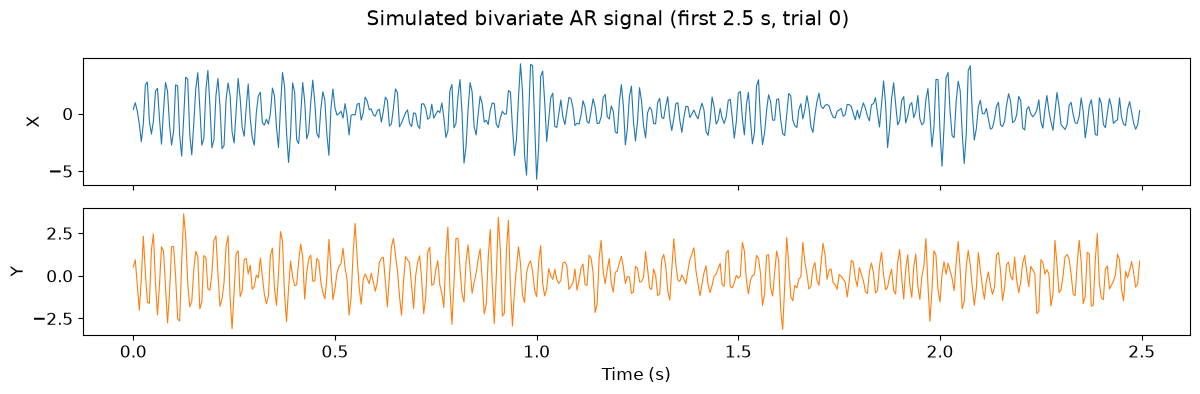

In [2]:
np.random.seed(42)

Fs = 200  # sampling rate (Hz)
N = 5000  # samples per trial
Trials = 1000  # number of independent trials
C = 0.25  # coupling strength Y -> X

cov = np.array([[0.5, 0.0], [0.0, 0.5]])

Z = ar_model_dhamala(N=N, Trials=Trials, Fs=Fs, C=C, t_start=0, t_stop=None, cov=cov)
# Z shape: (2, Trials, N); the GC functions expect (Trials, 2, N)
data = Z.transpose(1, 0, 2)
print("Data shape (channels, trials, samples):", Z.shape)

fig, axes = plt.subplots(2, 1, figsize=(12, 4), sharex=True)
t = np.arange(N) / Fs
axes[0].plot(t[:500], Z[0, 0, :500], lw=0.8)
axes[0].set_ylabel("X")
axes[1].plot(t[:500], Z[1, 0, :500], lw=0.8, color="C1")
axes[1].set_ylabel("Y")
axes[1].set_xlabel("Time (s)")
fig.suptitle("Simulated bivariate AR signal (first 2.5 s, trial 0)")
plt.tight_layout()

## 2. Parametric Granger Causality (Yule-Walker)

We fit a VAR model of the given `order` jointly across all trials via Yule-Walker, then derive the transfer function $H(f)$ and cross-spectrum $S(f)$ analytically and apply Geweke's spectral decomposition.

In [3]:
order = 10

ds_param = spectral_granger_causality(
    data, Fs, None, model="parametric", order=order
)
f_param = ds_param["freq"]
x2y_param, y2x_param = ds_param["x2y"], ds_param["y2x"]

print(
    f"Parametric  —  GC(X\u2192Y) mean: {x2y_param.mean():.4f}"
    f"   GC(Y\u2192X) mean: {y2x_param.mean():.4f}"
)

Parametric  —  GC(X→Y) mean: 0.0000   GC(Y→X) mean: 0.1431


## 3. Non-Parametric Granger Causality (Wilson Factorization)

We compute the cross-spectral matrix directly from the FFT and factorize it using the Wilson algorithm.

In [4]:
ds_fourier = spectral_granger_causality(
    data, Fs, None, spectral_method="fourier", Niterations=200, tol=1e-12, verbose=False
)

f_fourier = ds_fourier["freq"]
x2y_fourier, y2x_fourier = ds_fourier["x2y"], ds_fourier["y2x"]

print(
    f"Fourier  —  GC(X\u2192Y) mean: {x2y_fourier.mean():.4f}"
    f"   GC(Y\u2192X) mean: {y2x_fourier.mean():.4f}"
)

Fourier  —  GC(X→Y) mean: 0.0005   GC(Y→X) mean: 0.1434


## 4. Comparison Plot

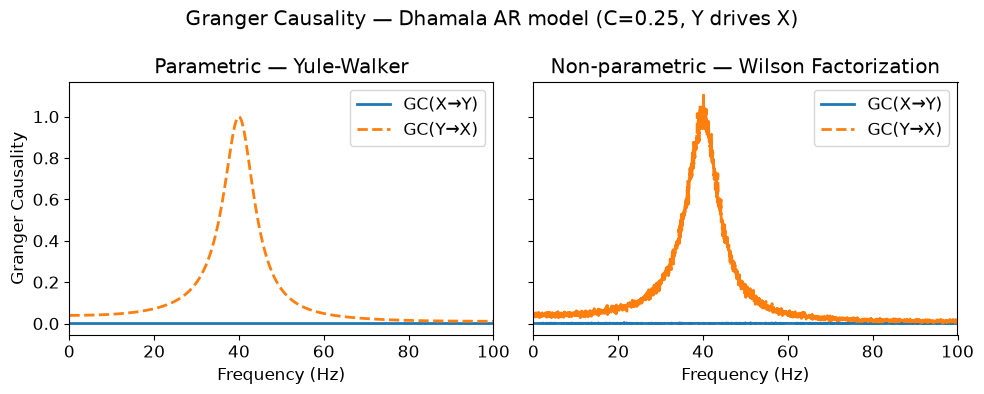

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

# Parametric (Yule-Walker)
axes[0].plot(f_param, x2y_param[0], label="GC(X\u2192Y)", lw=2)
axes[0].plot(f_param, y2x_param[0], label="GC(Y\u2192X)", lw=2, linestyle="--")
axes[0].set_title("Parametric — Yule-Walker")
axes[0].set_xlabel("Frequency (Hz)")
axes[0].set_ylabel("Granger Causality")
axes[0].legend()
axes[0].set_xlim([0, 100])

# Non-parametric (Fourier + Wilson)
axes[1].plot(f_fourier, x2y_fourier[0], label="GC(X\u2192Y)", lw=2)
axes[1].plot(f_fourier, y2x_fourier[0], label="GC(Y\u2192X)", lw=2, linestyle="--")
axes[1].set_title("Non-parametric — Wilson Factorization")
axes[1].set_xlabel("Frequency (Hz)")
axes[1].legend()
axes[1].set_xlim([0, 100])

fig.suptitle(f"Granger Causality — Dhamala AR model (C={C}, Y drives X)")
plt.tight_layout()

## 5. Summary

| Method | GC(Y→X) | GC(X→Y) |
|--------|---------|----------|
| Parametric (Yule-Walker) | > 0 | ≈ 0 |
| Non-parametric (Wilson) | > 0 | ≈ 0 |

Both methods correctly identify that **Y causes X** and not the reverse. The peak frequency reflects the resonance of the AR model (~40 Hz for the Dhamala model at Fs = 200 Hz).